# LangGraph State

In [1]:
from typing import List, Tuple
from typing_extensions import TypedDict
from langchain_core.documents import Document

class HybridRAGState(TypedDict):
    """Hybrid RAG 시스템의 상태를 정의하는 클래스"""
    question: str
    selected_node: str

    vector_docs: List[Tuple]

    tool_calls: List
    graph_docs: List[Tuple]
    reranked_docs: List[Document]
    relevant_docs: List[Document]

    answer: str

print("HybridRAGState 클래스 정의 완료!")


HybridRAGState 클래스 정의 완료!


# LangGraph Nodes

## Supervisor

### LLM

In [2]:
from langchain_ollama.chat_models import ChatOllama 

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.1,
    top_p=1.0,
    num_predict=256,
    keep_alive="5m"
)

### supervisor_node

In [3]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
import json

def supervisor_node(state: HybridRAGState) -> HybridRAGState:
    """
    Supervisor 노드: 질문을 분석하고 어떤 에이전트를 사용할지 결정합니다.
    """
    question = state["question"]
    
    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", 
        """
        당신은 Hybrid RAG 시스템의 Supervisor입니다.
        사용자의 질문을 분석하여 아래 검색 전략 중 하나를 선택하세요.

        =====================
        📌 카테고리 규칙 (절대 엄수)
        =====================
        허용되는 카테고리는 다음 6개뿐입니다:

            ["경제", "생활", "문화", "IT", "과학", "세계"]

        위 6개 외의 모든 단어는 절대 카테고리로 분류하지 마세요.

        - "부산", "날씨", "주식", "부동산", "정치", "음식" 등은 
        카테고리가 아니며, 어떤 경우에도 카테고리로 간주하면 안 됩니다.

        사용자가 다른 단어를 말하더라도, 
        당신은 위 목록 외에는 카테고리로 인정하지 않습니다.


        =====================
        📌 검색 전략 선택 기준
        =====================

        1. "graphdb"
            다음 조건 중 하나라도 만족하면 graphdb를 선택:
            - 질문에 허용된 카테고리 6개 중 하나가 명시됨
            - 언론사(Publisher)가 명시됨
            - 기자(Reporter)가 명시됨
            예:
                "경제 카테고리 최신 뉴스 알려줘"
                "조선일보 기사 뭐 있어?"
                "홍길동 기자가 쓴 뉴스 보여줘"

        2. "vectordb"
            다음 경우에는 vectordb를 선택:
            - 질문이 자연어 기반 의미적 검색을 필요로 하고
            - 카테고리/언론사/기자를 직접 언급하지 않음
            예:
                "요즘 부동산 시장 어떤가?"
                "반도체 전망 알려줘"
                "전기차 시장은 어떤 분위기야?"

        =====================
        📌 출력 형식 (반드시 지킬 것)
        =====================

        JSON 형식으로 답변하세요:
        {{
            "selected_node": "graphdb" or "vectordb",
            "reason": "선택 이유를 한 문장으로 설명"
        }}
        """),
        ("human", "질문: {question}")
    ])
    
    chain = supervisor_prompt | llm | StrOutputParser()
    result = chain.invoke({"question": question})
    
    try:
        # JSON 파싱 시도
        if result.strip().startswith("```"):
            # 마크다운 코드 블록 제거
            result = result.strip().split("```")[1]
            if result.startswith("json"):
                result = result[4:]
        decision = json.loads(result.strip())
    except:
        # 파싱 실패 시 기본값
        decision = {"selected_node": "vectordb", "reason": "파싱 오류로 기본값 사용"}
    
    selected_node = decision.get("selected_node", "vectordb")
    
    print(f"Supervisor 결정: {selected_node} - {decision.get('reason', '')}")
    
    return {
        **state,
        "selected_node": selected_node
    }

In [4]:
supervisor_result = supervisor_node({
    "question":"IT 관련 최신 뉴스 알려줘."
})

supervisor_result 

Supervisor 결정: graphdb - 질문이 IT 카테고리에 속하며, 최신 뉴스 검색을 요청하므로 graphdb를 선택합니다.


{'question': 'IT 관련 최신 뉴스 알려줘.', 'selected_node': 'graphdb'}

## VectorSearch

### Elasticsearch VectorStore

In [5]:
from common.elasticsearch.vector_store import ElasticsearchVectorStore
from langchain_ollama import OllamaEmbeddings

embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")
index_name = "naver_news"
vectorstore = ElasticsearchVectorStore(index_name, embeddings)


Elasticsearch 연결 성공!

버전: 8.12.1
클러스터 이름: elasticsearch-cluster
노드 이름: elasticsearch-node-1


### vector_search_node

In [6]:
def vector_search_node(state: HybridRAGState) -> HybridRAGState:
    question = state["question"]
    # 간단한 하이브리드 검색 결과 확인 예제
    docs_with_score =  vectorstore.hybrid_search_with_score(question, k=3)
    print(f"VectorSearch: {len(docs_with_score)}개의 문서를 검색했습니다.")
    
    return {
        **state,
        "vector_docs": docs_with_score
    }

In [7]:
vector_result = vector_search_node(supervisor_result)

vector_result

VectorSearch: 3개의 문서를 검색했습니다.


{'question': 'IT 관련 최신 뉴스 알려줘.',
 'selected_node': 'graphdb',
 'vector_docs': [(Document(metadata={'source': 'https://n.news.naver.com/mnews/article/421/0008630601', 'row': 19, '카테고리': '세계', '언론사': '뉴스1', '기자명': '신기림 기자', '발행일자': '2025-11-28 10:04:49'}, page_content='뉴스_제목: 파리 루브르박물관, 내년부터 비EU 관광객만 입장료 45% 인상\n뉴스_내용: 22유로 → 32유로 27일(현지시간) 프랑스 파리 루브르 박물관 유리 피라미드 인근에 프랑스 CRS(공화국보안대) 폭동 진압 경찰들이 서 있다. 2025.10.27. ⓒ 로이터=뉴스 (서울=뉴스1) 신기림 기자 = 프랑스 파리 루브르 박물관이 비(非) 유럽연합(EU) 국적자의 경우 입장료를 45% 인상한다고 27일(현지시간) 밝혔다. AFP 통신에 따르면 내년 1월 14일부터 비EU 국적자의 루브르 박물관 입장료는 기존 22유로에서 32유로로 인상된다. EU 지역 방문객들의 입장료는 그대로 22유로다. 박물관 측은 비EU 외국인 입장료 인상이 박물관의 자금 개선에 기여해 연간 최대 2300만 달러 수익 목표 달성에 도움을 줄 것이라고 밝혔다. 하지만 프랑스 민주노동총연맹은 모든 국적에 균일하게 적용되던 입장료가 폐지되면 "차별"로 인식될 것이라며 경고했다. 박물관의 2024년 보고서에 따르면 지난해 전체 방문객은 870만 명으로 이 중 69%가 외국인이었다. 미국인이 가장 많았고'),
   1.0),
  (Document(metadata={'source': 'https://n.news.naver.com/mnews/article/056/0012075511', 'row': 7, '카테고리': '생활/문화', '언론사': 'KBS', '기자명': '이정은 기자', '발행일자': '2025-11-28 08

## GraphSearch

### Tools

In [8]:
from langchain_core.tools import tool
from common.neo4j.connection import Neo4jConnection 

@tool
def search_news_by_category(category_name:str, limit_no:int=2) -> list:
    """
    category_name(카테고리)에 속하는 뉴스 기사 찾는 Cypher 쿼리를 이용하여, 
    실제 Neo4j DB에서 실행한 결과를 imit_no개 반환하는 검색 도구입니다.
    """
    conn = Neo4jConnection(
        uri="bolt://localhost:7687",
        user="neo4j",
        password="test1234"
    )
    template="NEWS_BY_CATEGORY"
    parameters={
        "category_name":category_name,
        "limit_no":limit_no
    }

    return conn.execute_query_templates(template, parameters)


In [9]:
result = search_news_by_category.invoke({
    "category_name":"세계", "limit_no":2
})

print(result)

Neo4j 연결 성공!
[(Document(metadata={'publisher_name': '뉴스1', 'reporter_name': '신기림 기자', 'publish_date': '2025-11-28 10:04:49', 'source': 'https://n.news.naver.com/mnews/article/421/0008630601'}, page_content='[뉴스 제목] 파리 루브르박물관, 내년부터 비EU 관광객만 입장료 45% 인상\n[뉴스 내용]\n22유로 → 32유로 27일(현지시간) 프랑스 파리 루브르 박물관 유리 피라미드 인근에 프랑스 CRS(공화국보안대) 폭동 진압 경찰들이 서 있다. 2025.10.27. ⓒ 로이터=뉴스 (서울=뉴스1) 신기림 기자 = 프랑스 파리 루브르 박물관이 비(非) 유럽연합(EU) 국적자의 경우 입장료를 45% 인상한다고 27일(현지시간) 밝혔다. AFP 통신에 따르면 내년 1월 14일부터 비EU 국적자의 루브르 박물관 입장료는 기존 22유로에서 32유로로 인상된다. EU 지역 방문객들의 입장료는 그대로 22유로다. 박물관 측은 비EU 외국인 입장료 인상이 박물관의 자금 개선에 기여해 연간 최대 2300만 달러 수익 목표 달성에 도움을 줄 것이라고 밝혔다. 하지만 프랑스 민주노동총연맹은 모든 국적에 균일하게 적용되던 입장료가 폐지되면 "차별"로 인식될 것이라며 경고했다. 박물관의 2024년 보고서에 따르면 지난해 전체 방문객은 870만 명으로 이 중 69%가 외국인이었다. 미국인이 가장 많았고 '), 0.5), (Document(metadata={'publisher_name': '헤럴드경제', 'reporter_name': '김지헌 기자', 'publish_date': '2025-11-28 11:20:18', 'source': 'https://n.news.naver.com/mnews/article/016/0002564552'}, page_content='[뉴스 제목] 백악관 총격사건에 격분한 트럼프 ‘우려국’ 영주

In [10]:
@tool
def search_news_by_publisher(publisher_name:str, limit_no:int=2) -> list:
    """
    publisher_name(언론사)가 발생한 뉴스 기사 찾는 Cypher 쿼리를 이용하여,
    실제 Neo4j DB에서 실행한 결과를 imit_no개 반환하는 검색 도구입니다.
    """
    conn = Neo4jConnection(
        uri="bolt://localhost:7687",
        user="neo4j",
        password="test1234"
    )
    template="NEWS_BY_PUBLISHER"
    parameters={
        "publisher_name":publisher_name,
        "limit_no":limit_no
    }

    return conn.execute_query_templates(template, parameters)

In [11]:
result = search_news_by_publisher.invoke({
    "publisher_name":"KBS", "limit_no":2
})

print(result)

[(Document(metadata={'publisher_name': 'KBS', 'reporter_name': '이정은 기자', 'publish_date': '2025-11-28 08:57:21', 'source': 'https://n.news.naver.com/mnews/article/056/0012075511'}, page_content='[뉴스 제목] ‘2026 부산 세계도서관정보대회’ 지원 국가위원회 출범\n[뉴스 내용]\n내년 부산에서 열리는 세계도서관정보대회를 지원할 위원회가 본격적으로 가동됩니다. 문화체육관광부는 오늘(28일) 오전 국회 의원회관에서 출범식을 갖고, 한국도서관협회 소속 ‘2026 부산 세계도서관정보대회(WLIC) 국가위원회’를 공식 출범한다고 밝혔습니다. 국가위원회는 국회와 중앙·지방정부, 학계, 민간에서 활동하던 전문가 16명으로 꾸려졌으며, 이들은 내년 열릴 부산 세계도서관정보대회 준비와 정책 협력 역할을 수행할 예정입니다. 공동위원장에는 차지호 더불어민주당 의원과 정연욱 국민의힘 의원이, 부위원장에는 김희섭 국립중앙도서관장·이준승 부산시 행정부시장·이지연 연세대 문헌정보학과 교수·황정근 국회도서관장이 각각 위촉됐습니다. 세계도서관정보대회는 1928년부터 시작돼 내년 90회째이며, 세계 도서관과 관련 정보 분야 전문가들이 한자리에 모여 현안을 논의하고 도서관의 미래를 그려나가는 세계 최대 규모의 국제회의입니다. 우리나라에서 세계도서관정보대회가 열리는 건 2006년 서울 대회 이'), 0.5)]


In [12]:
@tool
def search_news_by_reporter(reporter_name:str, limit_no:int=2) -> list:
    """
    reporter_name(기자명)가 작성한 뉴스 기사 찾는 Cypher 쿼리를 이용하여, 
    실제 Neo4j DB에서 실행한 결과를 imit_no개 반환하는 검색 도구입니다.
    """
    conn = Neo4jConnection(
        uri="bolt://localhost:7687",
        user="neo4j",
        password="test1234"
    )
    template="NEWS_BY_REPORTER"
    parameters={
        "reporter_name":reporter_name,
        "limit_no":limit_no
    }

    return conn.execute_query_templates(template, parameters)

In [13]:
result = search_news_by_reporter.invoke({
    "reporter_name":"임용우 기자", "limit_no":2
})

print(result)

[(Document(metadata={'publisher_name': '뉴스1', 'reporter_name': '임용우 기자', 'publish_date': '2025-11-28 11:00:00', 'source': 'https://n.news.naver.com/mnews/article/421/0008630778'}, page_content="[뉴스 제목] 1~10월 국세수입 37.1조 증가한 330.7조…기업 실적 개선에 법인·소득세↑\n[뉴스 내용]\n10월 세수 전년比 2.8조 늘어…법인세 7000억·소득세 9000억↑ 진도율 88.9%, 전년比 1.7%p↑…5년 평균과 유사 ⓒ News1 윤주희 디자이너 (세종=뉴스1) 임용우 기자 = 올해 1~10월 국세 수입이 지난해 같은 기간보다 37조 1000억 원 늘어난 것으로 집계됐다. 지난해와 올해 상반기 기업 실적 개선, 성과급 지급 확대 등이 이어지며 법인세와 소득세가 크게 증가한 영향이다. 기획재정부가 28일 발표한 '2025년 10월 국세수입 현황'에 따르면 10월 국세 수입은 41조 1000억 원으로 전년 동월(38조 3000억 원)보다 2조 8000억 원 증가했다. 법인세는 상반기 기업 실적 개선에 따른 중소기업 중간예납 분납분 증가, 이자·배당 원천소득 증가 등으로 7000억 원 늘었다. 소득세는 근로자 수 증가와 총급여 지급액 확대에 따른 근로소득세 증가로 9000억 원 증가했다. 부가가치세는 올해 2기 예정신고분 납부 증가와 환율 상승 영향 등으로 7000억 원 증"), 0.5)]


In [14]:
tools = [
    search_news_by_category, search_news_by_publisher, search_news_by_reporter
]

for tool in tools:
    print("=" * 50)
    print(f"Tool 이름: {tool.name}")
    print(f"Tool 설명: {tool.description}")
    print(f"Tool 인풋 파라미터: {tool.args}")
    print(f"Tool return_direct: {tool.return_direct}")

Tool 이름: search_news_by_category
Tool 설명: category_name(카테고리)에 속하는 뉴스 기사 찾는 Cypher 쿼리를 이용하여, 
실제 Neo4j DB에서 실행한 결과를 imit_no개 반환하는 검색 도구입니다.
Tool 인풋 파라미터: {'category_name': {'title': 'Category Name', 'type': 'string'}, 'limit_no': {'default': 2, 'title': 'Limit No', 'type': 'integer'}}
Tool return_direct: False
Tool 이름: search_news_by_publisher
Tool 설명: publisher_name(언론사)가 발생한 뉴스 기사 찾는 Cypher 쿼리를 이용하여,
실제 Neo4j DB에서 실행한 결과를 imit_no개 반환하는 검색 도구입니다.
Tool 인풋 파라미터: {'publisher_name': {'title': 'Publisher Name', 'type': 'string'}, 'limit_no': {'default': 2, 'title': 'Limit No', 'type': 'integer'}}
Tool return_direct: False
Tool 이름: search_news_by_reporter
Tool 설명: reporter_name(기자명)가 작성한 뉴스 기사 찾는 Cypher 쿼리를 이용하여, 
실제 Neo4j DB에서 실행한 결과를 imit_no개 반환하는 검색 도구입니다.
Tool 인풋 파라미터: {'reporter_name': {'title': 'Reporter Name', 'type': 'string'}, 'limit_no': {'default': 2, 'title': 'Limit No', 'type': 'integer'}}
Tool return_direct: False


### LLM with Tools

In [15]:
from dotenv import load_dotenv

# dotenv 파일에서 환경변수 로드
load_dotenv()

True

In [16]:
from langchain_openai import ChatOpenAI

llm_with_tools = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
).bind_tools(tools) # LLM에 등록된 tools 적용 

In [17]:
from langchain_core.messages import HumanMessage

test_message = HumanMessage(content="IT 뉴스 찾아줘.")

response = llm_with_tools.invoke([test_message])

print("테스트")
print(f"사용자: {test_message.content}")
print(f"AI 응답: {response.content}")
print(f"도구 호출 여부: {'있음' if response.tool_calls else '없음'}")

테스트
사용자: IT 뉴스 찾아줘.
AI 응답: 
도구 호출 여부: 있음


In [18]:
if response.tool_calls:
    print("요청된 도구 호출:")
    for tool_call in response.tool_calls:
        print(f"   - 도구명: {tool_call['name']}")
        print(f"   - 인자: {tool_call['args']}")

요청된 도구 호출:
   - 도구명: search_news_by_category
   - 인자: {'category_name': 'IT'}


In [19]:
result = search_news_by_category.invoke(tool_call['args'])

print(result)

[(Document(metadata={'publisher_name': '아시아경제', 'reporter_name': '노경조 기자', 'publish_date': '2025-11-28 10:56:44', 'source': 'https://n.news.naver.com/mnews/article/277/0005686177'}, page_content='[뉴스 제목] 3G·LTE 재할당에 5G 설비투자 의무 부여 \'적법\' 결론\n[뉴스 내용]\n정부 법률자문 "재량 따라 적정 수준 부과 가능" 이해민 의원 "취약지역 등 5G 투자 의무화해야" 정부가 3G·LTE 주파수 재할당 조건으로 취약지역 등에 5G 설비투자 의무를 부여하는 것은 적법한 재량권 행사라는 법적 해석이 나왔다. 픽사베이 국회 과학기술정보방송통신위원회 소속 이해민 조국혁신당 의원은 28일 과학기술정보통신부가 제출한 법률 자문 결과를 근거로 "3G·LTE 주파수 재할당에서 실내 및 취약지역을 중심으로 5G 설비 투자 의무를 반드시 포함해야 한다"고 밝혔다. 이 의원은 지난달 국정감사에서 통신사의 5G 설비투자 부진과 품질 저하 문제를 제기했다. 이 같은 상황이 지속되면 향후 3~5년간 품질 저하로 인한 이용자 피해는 물론이고, 전후방 산업 생태계까지 무너져 6G 경쟁력 확보에도 심각한 차질이 생길 것이라고 지적했다. 과기정통부는 최근 외부 법률 자문에서 "주파수 재할당은 \'재량 행위, 수익적 행정 행위\'로 규정돼 조건·부담 부과가 가능하다"는 해석을 받은 것으'), 0.5), (Document(metadata={'publisher_name': '파이낸셜뉴스', 'reporter_name': '주원규 기자', 'publish_date': '2025-11-28 15:32:19', 'source': 'https://n.news.naver.com/mnews/article/014/0005441516'}, page_content='[뉴스 제목] 넥슨, 시가총액 29조 돌파..."IP 성장 전략 성공"\n[

### select_graph_tool_node

In [20]:
from langchain_core.messages import SystemMessage
from langchain_core.messages import HumanMessage

def select_graph_tool_node(state: HybridRAGState) -> HybridRAGState:
    """
    사용자 요청을 분석하고 필요한 도구를 호출
    """
    # 시스템 프롬프트로 역할 부여
    system_prompt = SystemMessage(content="""
    당신은 도움이 되는 AI 개인 비서입니다. 
    사용자의 요청을 분석하여 적절한 도구를 사용해 도와주세요.
    
    사용 가능한 도구들:
    - search_news_by_category: 카테고리에 속하는 뉴스 기사 찾는 도구
    - search_news_by_publisher: 언론사가 발생한 뉴스 기사 찾는 도구
    - search_news_by_reporter: 기자가 작성한 뉴스 기사 찾는 도구
    """)
    
    messages = [system_prompt] + [HumanMessage(content=state["question"])]
    
    print("AI 에이전트가 요청을 분석 중...")
    response = llm_with_tools.invoke(messages)
    
    # 도구 호출이 있는지 확인
    if response.tool_calls:
        print(f"{len(response.tool_calls)}개의 도구를 사용합니다:")
        for tool_call in response.tool_calls:
            print(f"   - {tool_call['name']}: {tool_call['args']}")
    else:
        print("일반 대화로 응답합니다.")
    
    return {
        **state,
        "tool_calls": response.tool_calls}

In [21]:
response = select_graph_tool_node({"question":"IT 뉴스 찾아줘."})

AI 에이전트가 요청을 분석 중...
1개의 도구를 사용합니다:
   - search_news_by_category: {'category_name': 'IT', 'limit_no': 5}


In [22]:
response

{'question': 'IT 뉴스 찾아줘.',
 'tool_calls': [{'name': 'search_news_by_category',
   'args': {'category_name': 'IT', 'limit_no': 5},
   'id': 'call_2LfcJRROLZBIb5J0ZgnqntYK',
   'type': 'tool_call'}]}

### execution_graph_tool_node

In [23]:
def execution_graph_tool_node(state: HybridRAGState) -> HybridRAGState:
    """
    AI가 요청한 도구들을 실제로 실행하는 노드
    """
    tool_calls = state["tool_calls"]
    
    if not tool_calls:
        # 도구 호출이 없으면 아무것도 하지 않음
        return 
    
    docs_with_score = []
    
    # 각 도구 호출 실행
    for tool_call in tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        
        print(f"{tool_name} 실행 중... (인자: {tool_args})")
        
        # 도구 실행
        tool_function = next(tool for tool in tools if tool.name == tool_name)
        docs_with_score += tool_function.invoke(tool_args)

    print(f"GraphSearch: {len(docs_with_score)}개의 문서를 검색했습니다.")
    return {
        **state,
        "graph_docs": docs_with_score
    }

## Evaluate Documents

### rerank_with_score_node

In [24]:
def rerank_with_score_node(state: HybridRAGState) -> HybridRAGState:
    vector_docs = state.get("vector_docs", [])
    graph_docs = state.get("graph_docs", [])
    
    all_docs = vector_docs + graph_docs

    reranked_documents = sorted(all_docs, key=lambda doc: doc[1], reverse=True)

    return {
        **state,
        "reranked_docs": [
            doc for doc, score in reranked_documents if score >= 0.5
        ]
    }

### evaluate_with_llm_node

In [25]:
def evaluate_with_llm_node(state: HybridRAGState) -> HybridRAGState:
    reranked_docs = state['reranked_docs']
    question = state["question"]

    # 관련성 평가 프롬프트
    relevance_prompt = ChatPromptTemplate.from_messages([
        ("system", 
        """
        당신은 문서의 관련성을 평가하는 전문가입니다.

        주어진 질문과 문서가 얼마나 관련이 있는지 평가하세요.
        - 매우 관련있음: 5점
        - 관련있음: 4점  
        - 보통: 3점
        - 약간 관련있음: 2점
        - 관련없음: 1점

        점수만 숫자로 답변하세요 (1-5)."""),
        ("human", "질문: {question}\n\n문서: {document}")
    ])
    
    chain = relevance_prompt | llm | StrOutputParser()
    
    relevant_docs = []
    for doc in reranked_docs:
        try:
            score_str = chain.invoke({
                "question": question,
                "document": doc.page_content
            })
            score = float(score_str.strip())
            
            if score >= 3.0:  # 3점 이상만 관련 문서로 간주
                relevant_docs.append(doc)
                
        except ValueError:
            print(f"점수 파싱 오류: {score_str}")
            continue

    print(f"Evaluate : {len(relevant_docs)}개의 문서를 검색했습니다.")
    return {
        **state,
        "relevant_docs":relevant_docs
    }


## Final Answer

### answer_generator_node

In [26]:
def __add_source(answer:str, docs:list) -> str:
    answer += "\n\n**출처:**\n"
    for doc in docs:
        if doc.metadata['source'] in answer: # 중복 제거 
            continue 

        answer += f"- {doc.metadata['source']}\n"

    return answer

In [27]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

def answer_generator_node(state: HybridRAGState) -> HybridRAGState:
    
    question = state["question"]
    relevant_docs = state.get("relevant_docs", [])

    # 관련 문서들로 컨텍스트 생성
    context_parts = []
    for i, doc in enumerate(relevant_docs, 1):
        context_parts.append(f"문서 {i}:\n{doc.page_content}\n")
    context = "\n".join(context_parts)
    
    # 답변 생성 프롬프트
    prompt_template = ChatPromptTemplate.from_template(
    """다음 컨텍스트를 바탕으로 질문에 답변해주세요.
    답변은 명확하고 구체적으로 작성하세요.
    한국어로 답변하세요.

    컨텍스트:
    {context}

    질문: {question}

    답변:""")
    llm = ChatOpenAI(
        model="gpt-5-nano",
        reasoning_effort="high",        # 논리성 강화
    )
    chain = prompt_template | llm | StrOutputParser()
    answer = chain.invoke({
        "context": context,
        "question": question
    })

    return {
        **state,
        "answer": __add_source(answer, relevant_docs)
    }

# LangGraph Workflow

## Router Function

In [28]:
def route_after_supervisor(state: HybridRAGState) -> str:
    """
    Supervisor 결정에 따라 다음 노드를 선택하는 라우팅 함수
    """
    selected_node = state.get("selected_node", "vectordb")
    
    if selected_node == "vectordb":
        return "vector_search"
    else:
        return "select_graph_tool"

## Create LangGraph

In [29]:
from langgraph.graph import StateGraph, END, START

def create_hybrid_rag_workflow():
    """
    Hybrid RAG 워크플로우를 생성합니다.
    """
    
    ###############################
    # StateGraph 생성
    ###############################
    workflow = StateGraph(HybridRAGState)
    
    ###############################
    # 노드 추가
    ###############################
    workflow.add_node("supervisor", supervisor_node)
    workflow.add_node("vector_search", vector_search_node)
    workflow.add_node("select_graph_tool", select_graph_tool_node)
    workflow.add_node("execution_graph_tool", execution_graph_tool_node)
    workflow.add_node("rerank_with_score", rerank_with_score_node)
    workflow.add_node("evaluate_with_llm", evaluate_with_llm_node)
    workflow.add_node("answer_generator", answer_generator_node)
    
    ###############################
    # 엣지 추가
    ###############################
    workflow.add_edge(START, "supervisor")
    
    # Supervisor 결정에 따라 조건부 분기
    workflow.add_conditional_edges(
        "supervisor",
        route_after_supervisor,
        {
            "vector_search": "vector_search",
            "select_graph_tool": "select_graph_tool"
        }
    )
    
    
    workflow.add_edge("select_graph_tool", "execution_graph_tool")
    workflow.add_edge("execution_graph_tool", "vector_search")
    workflow.add_edge("vector_search", "rerank_with_score")
    workflow.add_edge("rerank_with_score", "evaluate_with_llm")
    workflow.add_edge("evaluate_with_llm", "answer_generator")
    workflow.add_edge("answer_generator", END)
    
    ###############################
    # 컴파일
    ###############################
    app = workflow.compile()
    
    print("Hybrid Agents RAG 워크플로우가 생성되었습니다!")
    return app


In [30]:
# Hybrid RAG 워크플로우 생성
hybrid_rag = create_hybrid_rag_workflow()


Hybrid Agents RAG 워크플로우가 생성되었습니다!


## Display LangGraph

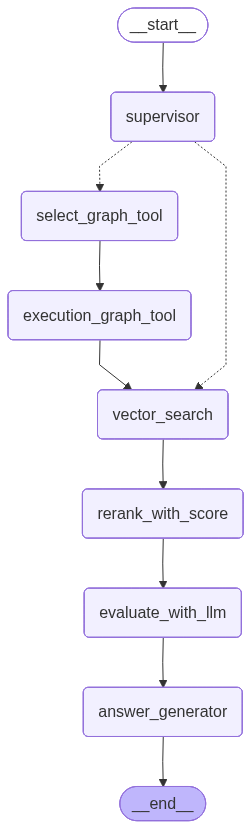

In [31]:
from IPython.display import Image, display

try:
    display(
        Image(
            hybrid_rag.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

# Hybrid RAG Test

In [32]:
def run_hybrid_rag(question: str, verbose: bool = True):
    """
    Hybrid RAG 시스템을 실행하는 메인 함수
    """
    print("=" * 60)
    print(f"Hybrid RAG 실행")
    print("=" * 60)
    print(f"질문: {question}")
    print("-" * 60)
    
    # 초기 상태 설정
    initial_state = {
        "question": question
    }
    
    try:
        # 워크플로우 실행
        result = hybrid_rag.invoke(
            initial_state,
            config={"configurable": {"thread_id": "rag_thread"}}
        )
        
        if verbose:
            print("\n" + "=" * 60)
            print("실행 결과 요약")
            print("=" * 60)
            print(f"선택된 노드: {result.get('selected_node', 'N/A')}")
            print(f"벡터 검색 문서 수: {len(result.get('vector_docs', []))}")
            print(f"그래프 검색 문서 수: {len(result.get('graph_docs', []))}")
            print(f"관련 문서 수: {len(result.get('reranked_docs', []))}")
            print("\n" + "=" * 60)
            print("최종 답변")
            print("=" * 60)
        
        print(result.get("answer", "답변을 생성할 수 없습니다."))
        
        return result
        
    except Exception as e:
        error_message = f"Hybrid RAG 실행 중 오류가 발생했습니다: {str(e)}"
        print(error_message)
        import traceback
        traceback.print_exc()

print("Hybrid RAG 실행 함수 구현 완료!")

Hybrid RAG 실행 함수 구현 완료!


## GraphDB + VectorDB

In [33]:
result1 = run_hybrid_rag("한겨레 언론사 뉴스 중에서 주택 관련 뉴스 찾아줘.")

Hybrid RAG 실행
질문: 한겨레 언론사 뉴스 중에서 주택 관련 뉴스 찾아줘.
------------------------------------------------------------
Supervisor 결정: graphdb - 질문에서 언론사(한겨레)를 명시하고 주택 관련 뉴스를 요청했으므로 graphdb를 선택합니다.
AI 에이전트가 요청을 분석 중...
2개의 도구를 사용합니다:
   - search_news_by_publisher: {'publisher_name': '한겨레', 'limit_no': 5}
   - search_news_by_category: {'category_name': '주택', 'limit_no': 5}
search_news_by_publisher 실행 중... (인자: {'publisher_name': '한겨레', 'limit_no': 5})
search_news_by_category 실행 중... (인자: {'category_name': '주택', 'limit_no': 5})
GraphSearch: 1개의 문서를 검색했습니다.
VectorSearch: 3개의 문서를 검색했습니다.
Evaluate : 3개의 문서를 검색했습니다.

실행 결과 요약
선택된 노드: graphdb
벡터 검색 문서 수: 3
그래프 검색 문서 수: 1
관련 문서 수: 3

최종 답변
다음이 한겨레 언론사(Hankyoreh, hani.co.kr) 주택 관련 기사입니다.

- 문서 2 / 문서 3: "아파트 보러 갔더니 '니하오'…외국인 집주인 56%가 중국인"
  - 요약: 6월 말 국내 외국인 소유 주택이 약 10만4천가구(10만4065가구)로 증가, 전체 주택의 0.53% 차지. 주택 소유 지역은 수도권이 72.5%(7만5484가구), 경기도가 4만794가구(39.2%)로 가장 많음. 외국인 집주인의 국적 중 56%가 중국인이라는 통계가 제시됨. 자료 출처는 국토교통부의 외국인 토지·주택 보유 통계이며, 기사 작성은 김명진 기자. 문서 3은 문서

## VectorDB

In [34]:
result2 = run_hybrid_rag("박물관 관련 뉴스 조회해줘.")

Hybrid RAG 실행
질문: 박물관 관련 뉴스 조회해줘.
------------------------------------------------------------
Supervisor 결정: vectordb - 질문이 박물관이라는 특정 카테고리를 언급하지만, 언론사나 기자를 직접 언급하지 않아 vectordb를 선택합니다.
VectorSearch: 3개의 문서를 검색했습니다.
Evaluate : 1개의 문서를 검색했습니다.

실행 결과 요약
선택된 노드: vectordb
벡터 검색 문서 수: 3
그래프 검색 문서 수: 0
관련 문서 수: 1

최종 답변
다음은 제공된 컨텍스트를 바탕으로 한 박물관 관련 뉴스 요약입니다.

- 대상 박물관: 파리 루브르 박물관
- 주요 내용: 비EU 국적자의 입장료를 45% 인상
  - 비EU 가격: 22유로 → 32유로
  - 적용 시점: 내년 1월 14일부터
  - EU 지역 방문객 입장료: 22유로 유지
- 인상 목적: 박물관 재정 개선 및 연간 최대 2,300만 달러 수익 목표 달성에 기여
- 반응 및 논쟁: 프랑스 민주노동총연맹이 차별 문제를 제기하며 모든 국적에 균일하게 적용되던 정책의 폐지를 경고
- 방문객 현황(루브르 2024년 보고서): 지난해 방문객 870만 명, 이 중 69%가 외국인
- 외국인 구성: 미국인이 가장 많았다고 보도
- 주요 출처: AFP 통신 및 로이터 보도에 따라 보도

필요하면 원문 기사 링크나 자세한 수치를 추가로 정리해 드리겠습니다.

**출처:**
- https://n.news.naver.com/mnews/article/421/0008630601

